# **Task C**

- Name : Vaishnavi Agarwal
- Roll No.: 230150028

# Importing Libraries

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# DFT Matrix Generating function

In [13]:
def gen_DFT_matrix(N):
    F = np.zeros((N, N), dtype=complex)
    for m in range(N):
        for n in range(N):
            F[m, n] = (1/np.sqrt(N)) * np.exp(-1j * 2 * np.pi * m * n / N)
    return F

# Plotting func

In [14]:
def plot_matrix_heatmaps(M, title):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(M.real, cmap="viridis")
    plt.colorbar()
    plt.title(f"{title} (Real)")
    
    plt.subplot(1, 2, 2)
    plt.imshow(M.imag, cmap="viridis")
    plt.colorbar()
    plt.title(f"{title} (Imag)")
    plt.tight_layout()
    plt.show()

# **(a) Structure and Visualization**

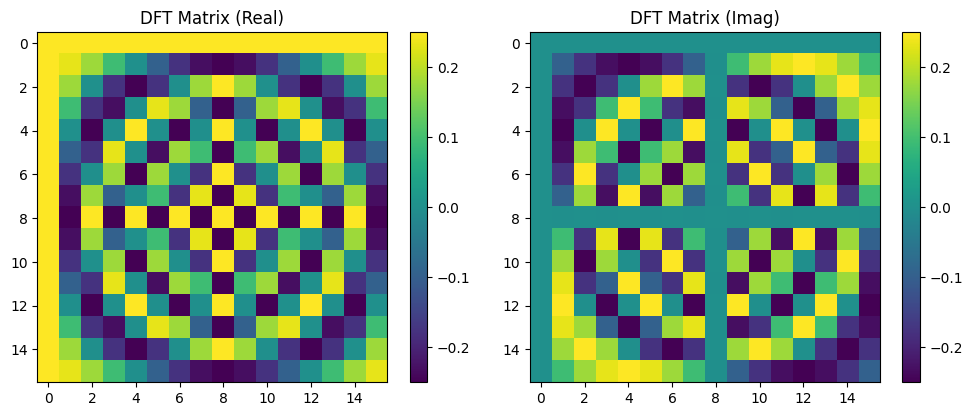

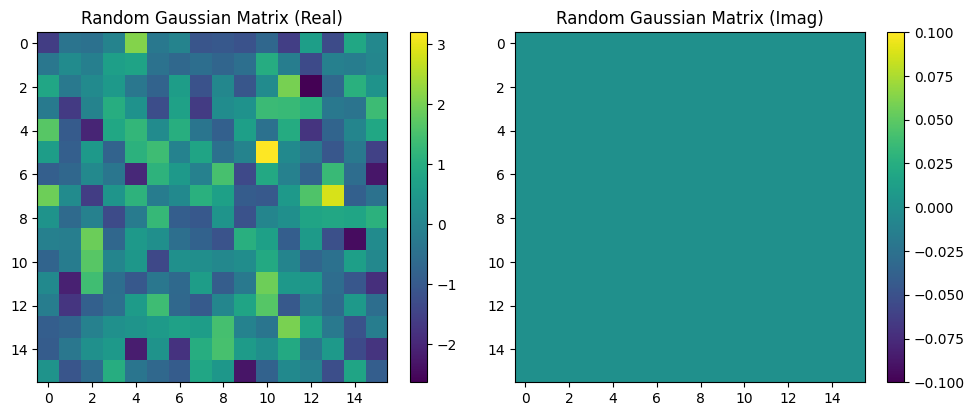

In [15]:
N = 16
F = gen_DFT_matrix(N)
R = np.random.randn(N, N)

plot_matrix_heatmaps(F, "DFT Matrix")
plot_matrix_heatmaps(R, "Random Gaussian Matrix")

# **(b) Orthogonality and Energy Preservation**

In [16]:
# DFT orthogonality check
I_F = np.round(F.conj().T @ F,6)
print("DFT Matrix F*F =\n", I_F)
# Random matrix check
I_R = R.T @ R
print("Random Matrix R^T R (not identity):\n", I_R)


DFT Matrix F*F =
 [[ 1.+0.j -0.+0.j -0.+0.j -0.+0.j -0.-0.j -0.-0.j -0.-0.j  0.+0.j  0.-0.j
   0.-0.j -0.-0.j  0.-0.j  0.-0.j  0.+0.j  0.+0.j  0.-0.j]
 [-0.-0.j  1.-0.j -0.+0.j  0.+0.j -0.+0.j -0.+0.j -0.-0.j  0.-0.j -0.-0.j
   0.-0.j -0.+0.j -0.-0.j  0.-0.j  0.-0.j  0.+0.j -0.+0.j]
 [-0.-0.j -0.-0.j  1.+0.j -0.-0.j  0.-0.j  0.+0.j -0.-0.j  0.-0.j  0.-0.j
  -0.-0.j  0.+0.j  0.-0.j  0.-0.j  0.-0.j  0.-0.j  0.+0.j]
 [-0.-0.j  0.-0.j -0.+0.j  1.-0.j  0.-0.j -0.-0.j -0.+0.j -0.-0.j  0.-0.j
   0.+0.j  0.+0.j -0.+0.j  0.-0.j -0.-0.j -0.-0.j  0.+0.j]
 [-0.+0.j -0.-0.j  0.-0.j  0.+0.j  1.+0.j -0.-0.j  0.+0.j -0.+0.j -0.-0.j
  -0.+0.j  0.-0.j -0.-0.j  0.-0.j -0.+0.j -0.-0.j  0.-0.j]
 [-0.+0.j -0.-0.j  0.-0.j -0.+0.j -0.+0.j  1.-0.j -0.+0.j -0.+0.j -0.+0.j
   0.+0.j -0.-0.j -0.-0.j -0.-0.j  0.-0.j -0.+0.j -0.+0.j]
 [-0.+0.j -0.+0.j -0.+0.j -0.-0.j  0.-0.j -0.-0.j  1.-0.j  0.+0.j -0.-0.j
   0.-0.j -0.+0.j  0.-0.j -0.-0.j  0.+0.j -0.+0.j  0.+0.j]
 [ 0.-0.j  0.+0.j  0.+0.j -0.+0.j -0.-0.j -0.-0.j  

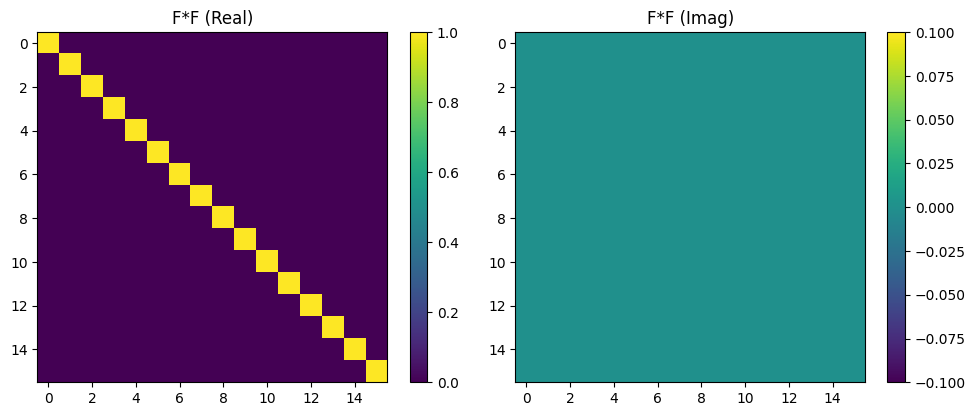

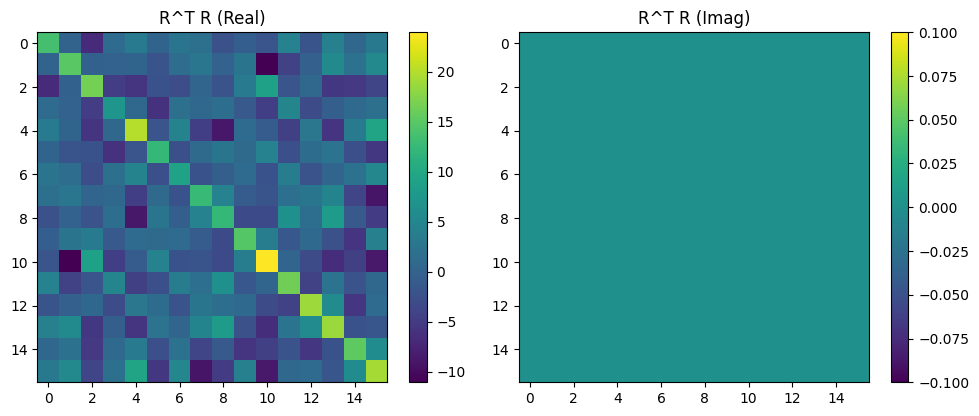

In [17]:
# to visualise the Unitarity nature of the matrices better, we have the heat maps
plot_matrix_heatmaps(I_F, "F*F")
plot_matrix_heatmaps(I_R, "R^T R")

# **(c) Condition Number Exploration**

In [18]:

def cond_number(A):
    return np.linalg.norm(A, 2) * np.linalg.norm(np.linalg.inv(A), 2)


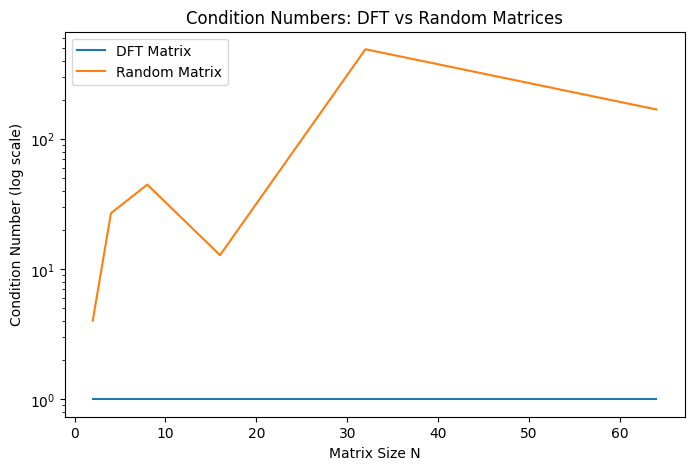

In [22]:


Ns = [2, 4, 8, 16, 32, 64]
cond_F = []
cond_R = []
np.random.seed(10)
for N in Ns:
    F = gen_DFT_matrix(N)
    R = np.random.randn(N, N)
    
    cond_F.append(cond_number(F)) 
    cond_R.append(cond_number(R))

plt.figure(figsize=(8,5))
plt.plot(Ns, cond_F, label="DFT Matrix")
plt.plot(Ns, cond_R, label="Random Matrix")
plt.yscale("log")
plt.xlabel("Matrix Size N")
plt.ylabel("Condition Number (log scale)")
plt.title("Condition Numbers: DFT vs Random Matrices")
plt.legend()
plt.show()


For unitary F, the value for conditional number remains 1.

For a random matrix R, it increases with increasing value of N.


# **(d) Bonus — Usefulness of Random Matrices**

**Compressed Sensing**

- Random matrices are often used as measurement matrices.

- They satisfy the Restricted Isometry Property (RIP) with high probability, ensuring that sparse signals can be reconstructed reliably.

**Dimension Reduction (Johnson–Lindenstrauss Lemma)**

- Random projections are used to embed high-dimensional data into lower dimensions while approximately preserving distances.

- Used in large-scale machine learning, fast approximate nearest neighbor search, etc.

**Randomized Numerical Linear Algebra**

- Speeding up computations for SVD, PCA, regression by using random sketching matrices.

**Wireless Communications / Information Theory**

- Modeling channels (MIMO systems, fading, etc.).

- Random matrix theory helps predict eigenvalue distributions, useful for analyzing system capacity.



**These are the places where using a random matrix is more beneficial than using a DFT matrix**
